# Eksperimen Operasi Kombinasi Kernel pada Gaussian Process Regression
**Bimbingan Tugas Akhir #5**

Pada eksperimen ini, kita menguji 4 kombinasi kernel terhadap 2 jenis fungsi pembangkit data (*ground-truth*):
1. **$k_{\mathrm{RBF+Per}} = k_{\mathrm{RBF}} + k_{\mathrm{Per}}$**
2. **$k_{\mathrm{RBF \times Per}} = k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$**
3. **$k_{\mathrm{Lin+Per}} = k_{\mathrm{Lin}} + k_{\mathrm{Per}}$**
4. **$k_{\mathrm{Lin \times Per}} = k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$**

---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi style grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 9.5
plt.rcParams['axes.labelsize'] = 10.5
plt.rcParams['axes.titlesize'] = 11.5
plt.rcParams['legend.fontsize'] = 8.5

# -------------------------------------------------------------
# 1. Definisi Kernel Dasar
# -------------------------------------------------------------
def kernel_rbf(X1, X2, sigma_f=1.0, lengthscale=1.0):
    dist_sq = (X1 - X2.T)**2
    return (sigma_f**2) * np.exp(-0.5 * dist_sq / (lengthscale**2))

def kernel_periodic(X1, X2, sigma_p=1.0, lengthscale=1.0, period=2.0):
    dist = np.abs(X1 - X2.T)
    sin_term = np.sin(np.pi * dist / period)
    return (sigma_p**2) * np.exp(-2.0 * (sin_term**2) / (lengthscale**2))

def kernel_linear(X1, X2, sigma_b=0.2, sigma_v=1.0, c=0.0):
    return (sigma_b**2) + (sigma_v**2) * (X1 - c) * (X2.T - c)

# -------------------------------------------------------------
# 2. Solver GP Regression (Cholesky)
# -------------------------------------------------------------
def gp_predict(X_train, y_train, X_test, kernel_fn, sigma_n=0.15):
    K = kernel_fn(X_train, X_train) + (sigma_n**2) * np.eye(len(X_train))
    K_s = kernel_fn(X_train, X_test)
    K_ss = kernel_fn(X_test, X_test) + 1e-7 * np.eye(len(X_test))
    
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    
    # Mean
    mu_s = K_s.T @ alpha
    
    # Variance
    v = np.linalg.solve(L, K_s)
    cov_s = K_ss - v.T @ v
    var_s = np.diag(cov_s)
    std_s = np.sqrt(np.maximum(var_s, 1e-8))
    
    return mu_s.flatten(), std_s.flatten()

# Definisi 4 Model Kernel
period_val = 2.0

def k_rbf_sum(Xa, Xb):
    return kernel_rbf(Xa, Xb, sigma_f=1.0, lengthscale=3.0) + kernel_periodic(Xa, Xb, sigma_p=1.2, lengthscale=1.2, period=period_val)

def k_rbf_prod(Xa, Xb):
    return kernel_rbf(Xa, Xb, sigma_f=1.2, lengthscale=5.0) * kernel_periodic(Xa, Xb, sigma_p=1.0, lengthscale=1.0, period=period_val)

def k_lin_sum(Xa, Xb):
    return kernel_linear(Xa, Xb, sigma_b=0.3, sigma_v=0.1, c=0.0) + kernel_periodic(Xa, Xb, sigma_p=1.2, lengthscale=1.0, period=period_val)

def k_lin_prod(Xa, Xb):
    return kernel_linear(Xa, Xb, sigma_b=0.05, sigma_v=0.2, c=0.0) * kernel_periodic(Xa, Xb, sigma_p=1.0, lengthscale=1.0, period=period_val)

print("Setup fungsi kernel dan solver GP berhasil.")


Setup fungsi kernel dan solver GP berhasil.


## 1. Eksperimen 1: Fungsi Asli Aditif / Superposisi

Fungsi asli yang digunakan:
$$f_1(x) = \sin(0{,}6 x) + 1{,}2 \sin\left(\frac{2\pi x}{2{,}0}\right)$$
dengan $N = 67$ titik data observasi $y_i = f_1(x_i) + \varepsilon_i, \; \varepsilon_i \sim \mathcal{N}(0, 0{,}15^2)$ pada rentang $x \in [-10, 10]$.


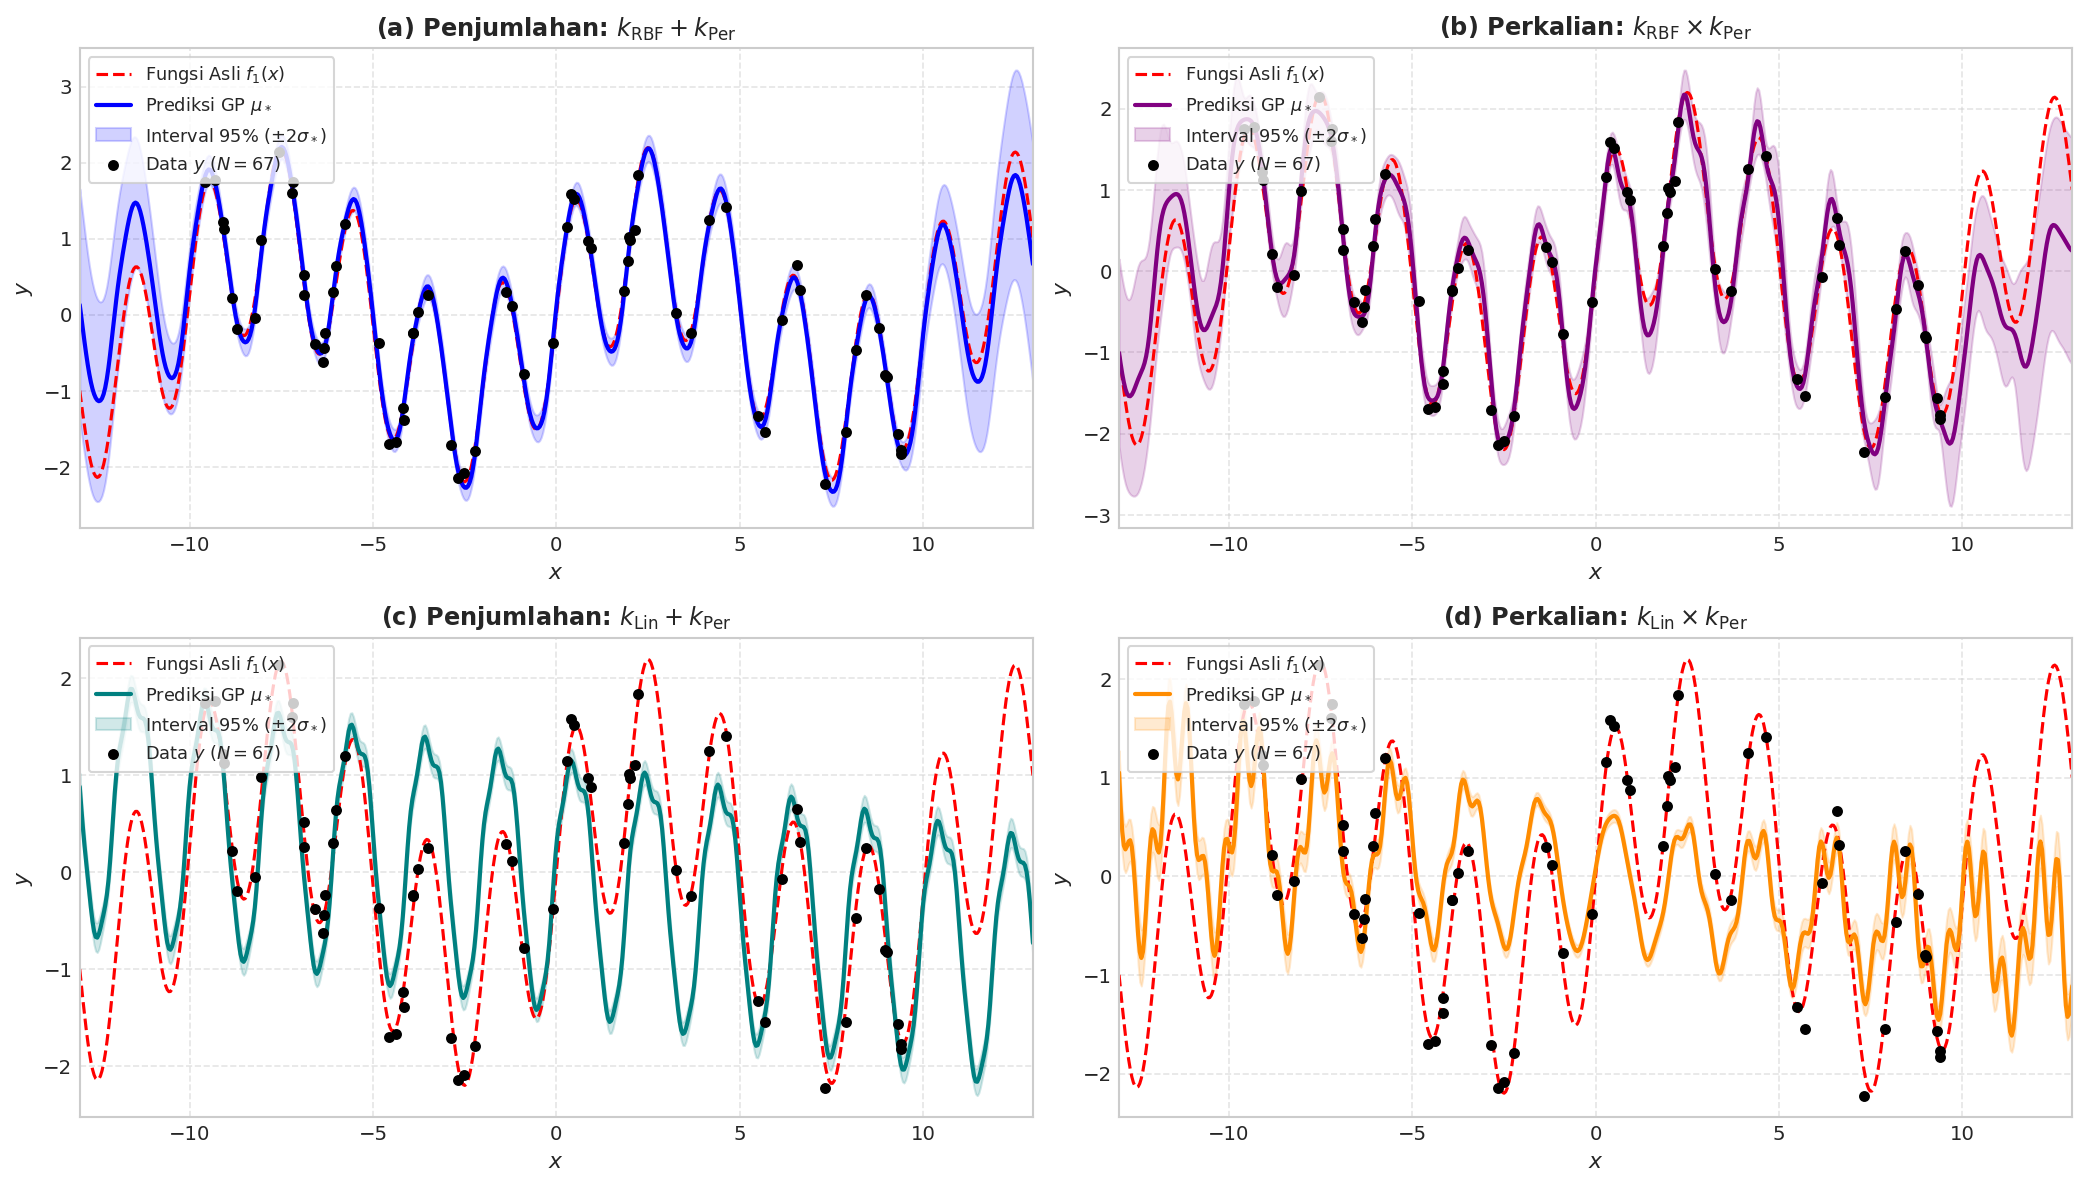

In [2]:
np.random.seed(42)
N_points = 67
X_test = np.linspace(-13.0, 13.0, 600)[:, None]

# Data Latih Kasus 1
X1_train = np.sort(np.random.uniform(-10, 10, N_points))[:, None]
f1_true_train = np.sin(0.6 * X1_train) + 1.2 * np.sin(2.0 * np.pi * X1_train / period_val)
y1_train = f1_true_train + np.random.normal(0, 0.15, size=X1_train.shape)
f1_true_test = np.sin(0.6 * X_test) + 1.2 * np.sin(2.0 * np.pi * X_test / period_val)

mu1_rbf_sum, std1_rbf_sum = gp_predict(X1_train, y1_train, X_test, k_rbf_sum, sigma_n=0.15)
mu1_rbf_prod, std1_rbf_prod = gp_predict(X1_train, y1_train, X_test, k_rbf_prod, sigma_n=0.15)
mu1_lin_sum, std1_lin_sum = gp_predict(X1_train, y1_train, X_test, k_lin_sum, sigma_n=0.15)
mu1_lin_prod, std1_lin_prod = gp_predict(X1_train, y1_train, X_test, k_lin_prod, sigma_n=0.15)

fig1, axes1 = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

# (a) RBF + Per
axes1[0, 0].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[0, 0].plot(X_test, mu1_rbf_sum, 'b-', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[0, 0].fill_between(X_test.flatten(), mu1_rbf_sum - 2*std1_rbf_sum, mu1_rbf_sum + 2*std1_rbf_sum, color='blue', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[0, 0].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[0, 0].set_title(r'(a) Penjumlahan: $k_{\mathrm{RBF}} + k_{\mathrm{Per}}$', fontweight='bold')
axes1[0, 0].set_xlabel('$x$'); axes1[0, 0].set_ylabel('$y$'); axes1[0, 0].set_xlim(-13.0, 13.0)
axes1[0, 0].legend(loc='upper left', frameon=True); axes1[0, 0].grid(True, linestyle='--', alpha=0.5)

# (b) RBF * Per
axes1[0, 1].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[0, 1].plot(X_test, mu1_rbf_prod, 'purple', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[0, 1].fill_between(X_test.flatten(), mu1_rbf_prod - 2*std1_rbf_prod, mu1_rbf_prod + 2*std1_rbf_prod, color='purple', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[0, 1].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[0, 1].set_title(r'(b) Perkalian: $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes1[0, 1].set_xlabel('$x$'); axes1[0, 1].set_ylabel('$y$'); axes1[0, 1].set_xlim(-13.0, 13.0)
axes1[0, 1].legend(loc='upper left', frameon=True); axes1[0, 1].grid(True, linestyle='--', alpha=0.5)

# (c) Lin + Per
axes1[1, 0].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[1, 0].plot(X_test, mu1_lin_sum, 'teal', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[1, 0].fill_between(X_test.flatten(), mu1_lin_sum - 2*std1_lin_sum, mu1_lin_sum + 2*std1_lin_sum, color='teal', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[1, 0].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[1, 0].set_title(r'(c) Penjumlahan: $k_{\mathrm{Lin}} + k_{\mathrm{Per}}$', fontweight='bold')
axes1[1, 0].set_xlabel('$x$'); axes1[1, 0].set_ylabel('$y$'); axes1[1, 0].set_xlim(-13.0, 13.0)
axes1[1, 0].legend(loc='upper left', frameon=True); axes1[1, 0].grid(True, linestyle='--', alpha=0.5)

# (d) Lin * Per
axes1[1, 1].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[1, 1].plot(X_test, mu1_lin_prod, 'darkorange', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[1, 1].fill_between(X_test.flatten(), mu1_lin_prod - 2*std1_lin_prod, mu1_lin_prod + 2*std1_lin_prod, color='darkorange', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[1, 1].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[1, 1].set_title(r'(d) Perkalian: $k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes1[1, 1].set_xlabel('$x$'); axes1[1, 1].set_ylabel('$y$'); axes1[1, 1].set_xlim(-13.0, 13.0)
axes1[1, 1].legend(loc='upper left', frameon=True); axes1[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 2. Eksperimen 2: Fungsi Asli Multiplikatif / Modulasi Amplitudo

Fungsi asli yang digunakan:
$$f_2(x) = 0{,}2 x \sin\left(\frac{2\pi x}{2{,}0}\right)$$
dengan $N = 67$ titik data observasi $y_i = f_2(x_i) + \varepsilon_i, \; \varepsilon_i \sim \mathcal{N}(0, 0{,}15^2)$ pada rentang $x \in [-10, 10]$.


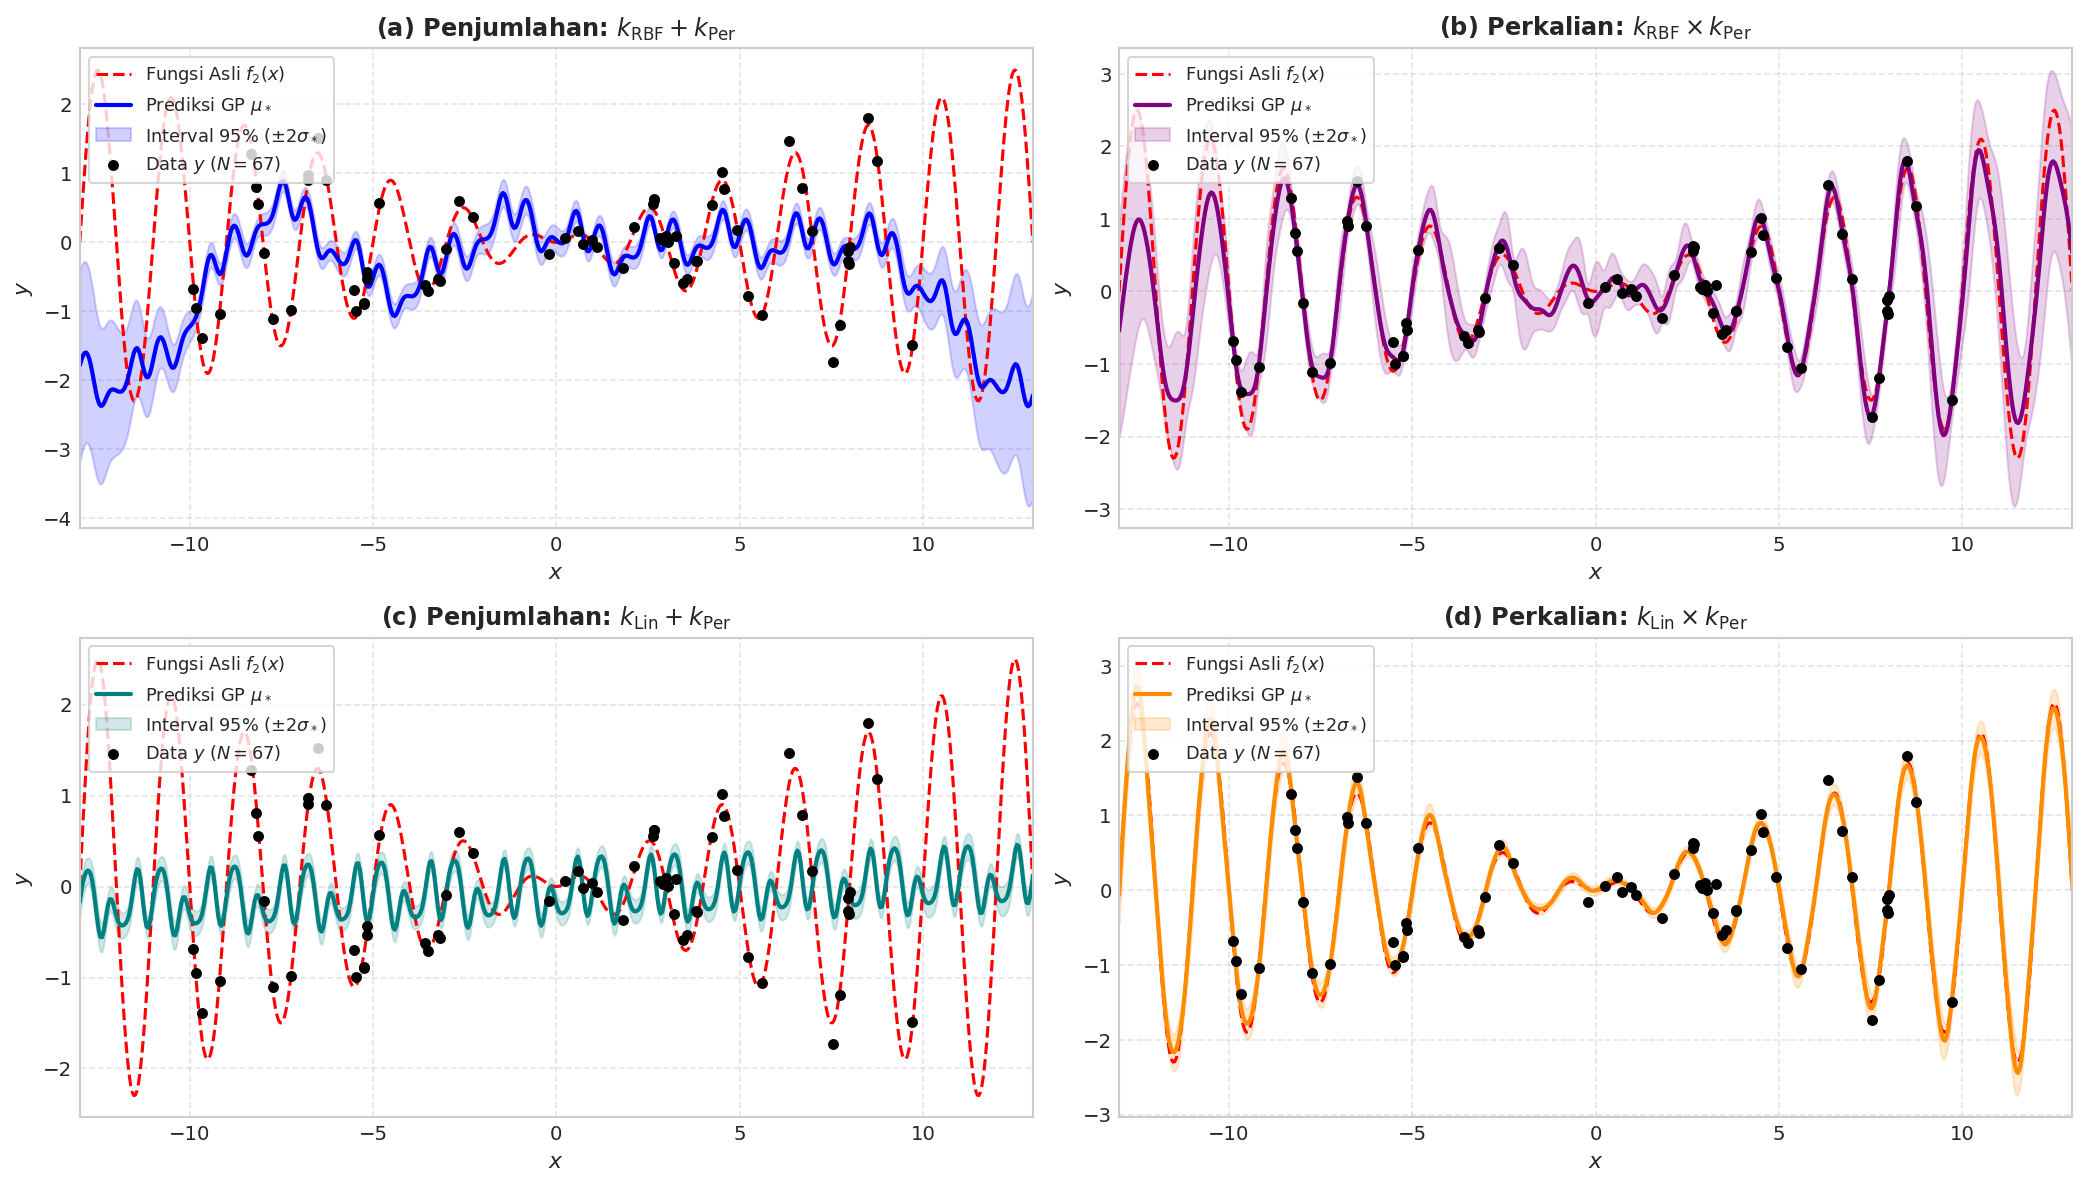

In [3]:
# Data Latih Kasus 2
X2_train = np.sort(np.random.uniform(-10, 10, N_points))[:, None]
f2_true_train = 0.2 * X2_train * np.sin(2.0 * np.pi * X2_train / period_val)
y2_train = f2_true_train + np.random.normal(0, 0.15, size=X2_train.shape)
f2_true_test = 0.2 * X_test * np.sin(2.0 * np.pi * X_test / period_val)

mu2_rbf_sum, std2_rbf_sum = gp_predict(X2_train, y2_train, X_test, k_rbf_sum, sigma_n=0.15)
mu2_rbf_prod, std2_rbf_prod = gp_predict(X2_train, y2_train, X_test, k_rbf_prod, sigma_n=0.15)
mu2_lin_sum, std2_lin_sum = gp_predict(X2_train, y2_train, X_test, k_lin_sum, sigma_n=0.15)
mu2_lin_prod, std2_lin_prod = gp_predict(X2_train, y2_train, X_test, k_lin_prod, sigma_n=0.15)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

# (a) RBF + Per
axes2[0, 0].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[0, 0].plot(X_test, mu2_rbf_sum, 'b-', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[0, 0].fill_between(X_test.flatten(), mu2_rbf_sum - 2*std2_rbf_sum, mu2_rbf_sum + 2*std2_rbf_sum, color='blue', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[0, 0].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[0, 0].set_title(r'(a) Penjumlahan: $k_{\mathrm{RBF}} + k_{\mathrm{Per}}$', fontweight='bold')
axes2[0, 0].set_xlabel('$x$'); axes2[0, 0].set_ylabel('$y$'); axes2[0, 0].set_xlim(-13.0, 13.0)
axes2[0, 0].legend(loc='upper left', frameon=True); axes2[0, 0].grid(True, linestyle='--', alpha=0.5)

# (b) RBF * Per
axes2[0, 1].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[0, 1].plot(X_test, mu2_rbf_prod, 'purple', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[0, 1].fill_between(X_test.flatten(), mu2_rbf_prod - 2*std2_rbf_prod, mu2_rbf_prod + 2*std2_rbf_prod, color='purple', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[0, 1].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[0, 1].set_title(r'(b) Perkalian: $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes2[0, 1].set_xlabel('$x$'); axes2[0, 1].set_ylabel('$y$'); axes2[0, 1].set_xlim(-13.0, 13.0)
axes2[0, 1].legend(loc='upper left', frameon=True); axes2[0, 1].grid(True, linestyle='--', alpha=0.5)

# (c) Lin + Per
axes2[1, 0].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[1, 0].plot(X_test, mu2_lin_sum, 'teal', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[1, 0].fill_between(X_test.flatten(), mu2_lin_sum - 2*std2_lin_sum, mu2_lin_sum + 2*std2_lin_sum, color='teal', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[1, 0].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[1, 0].set_title(r'(c) Penjumlahan: $k_{\mathrm{Lin}} + k_{\mathrm{Per}}$', fontweight='bold')
axes2[1, 0].set_xlabel('$x$'); axes2[1, 0].set_ylabel('$y$'); axes2[1, 0].set_xlim(-13.0, 13.0)
axes2[1, 0].legend(loc='upper left', frameon=True); axes2[1, 0].grid(True, linestyle='--', alpha=0.5)

# (d) Lin * Per
axes2[1, 1].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[1, 1].plot(X_test, mu2_lin_prod, 'darkorange', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[1, 1].fill_between(X_test.flatten(), mu2_lin_prod - 2*std2_lin_prod, mu2_lin_prod + 2*std2_lin_prod, color='darkorange', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[1, 1].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[1, 1].set_title(r'(d) Perkalian: $k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes2[1, 1].set_xlabel('$x$'); axes2[1, 1].set_ylabel('$y$'); axes2[1, 1].set_xlim(-13.0, 13.0)
axes2[1, 1].legend(loc='upper left', frameon=True); axes2[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
